In [1]:
import json
from urllib.request import urlopen
import json
import numpy as np
import matplotlib.pyplot as plt
import os


['.ipynb_checkpoints',
 '1790706663-vna-noise-power-scan.json',
 '1790708661-vna-noise-power-scan.json',
 '1790710475-vna-noise-power-scan.json',
 'index.html',
 'load-file.php',
 'readme.html',
 'README.md',
 'save-file.php',
 'spore.js',
 'spore.php',
 'Untitled.ipynb']

In [7]:
files = os.listdir('.')
power_scans = []
for file in files:
    if "vna-noise-power-scan" in file:
        power_scans.append(file)
        print(file)

1790706663-vna-noise-power-scan.json
1790708661-vna-noise-power-scan.json
1790710475-vna-noise-power-scan.json


In [8]:
scans = []
for file_name in power_scans:
    f = open(file_name)
    rawdata = f.read()
    f.close()
    scans.append(json.loads(rawdata))

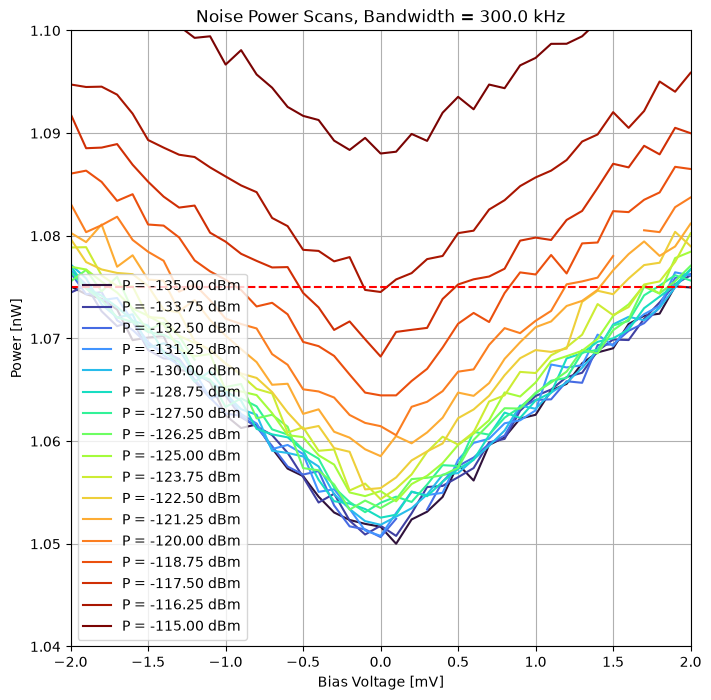

In [53]:
legend = []
fig, ax = plt.subplots(figsize=(8, 8))    
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0, 1,17)))

for index in np.arange(17):
    plt.plot(1000*np.array(scans[2]['noise_bias'])*2/200,np.array(scans[2]['noise'][index])/1e-9)
    legend.append(f"P = {scans[2]['power'][index] - 25 - 60:.2f} dBm")
plt.legend(legend,loc='lower left')
plt.xlim(-2,2)
plt.ylim(1.04,1.1)
plt.xlabel('Bias Voltage [mV]')
plt.ylabel('Power [nW]')
plt.grid()
plt.title('Noise Power Scans, Bandwidth = '  + str(scans[2]['rbw']/1000) + " kHz")
plt.axhline(y=1.075, color='r', linestyle='--', label='Threshold')

Text(0.5, 1.0, 'Noise Power Scans, Bandwidth = 1.0 MHz')

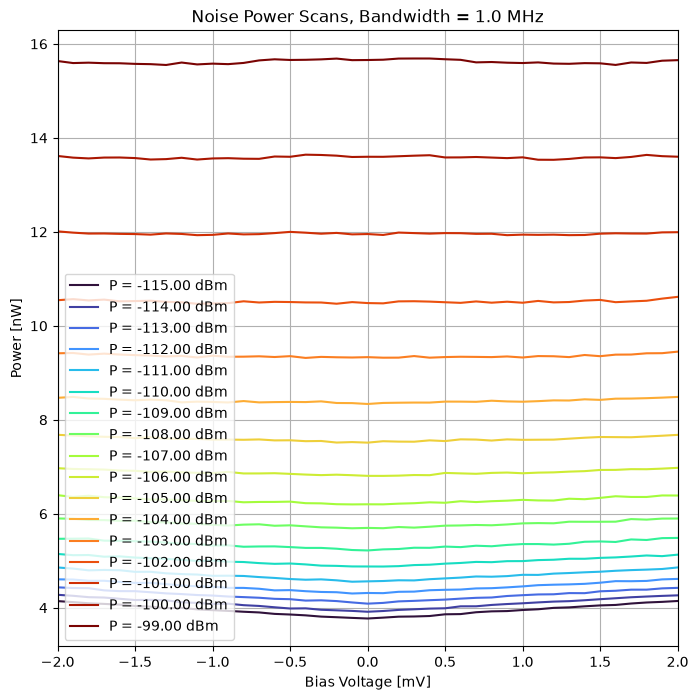

In [54]:
legend = []
fig, ax = plt.subplots(figsize=(8, 8))    
plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0, 1,17)))

for index in np.arange(17):
    plt.plot(1000*np.array(scans[0]['noise_bias'])*2/200,np.array(scans[0]['noise'][index])/1e-9)
    legend.append(f"P = {scans[0]['power'][index] - 25 - 60:.2f} dBm")
plt.legend(legend,loc='lower left')
plt.xlim(-2,2)
#plt.ylim(1.04,1.1)
plt.xlabel('Bias Voltage [mV]')
plt.ylabel('Power [nW]')
plt.grid()
plt.title('Noise Power Scans, Bandwidth = '  + str(scans[0]['rbw']/1e6) + " MHz")
#plt.axhline(y=1.075, color='r', linestyle='--', label='Threshold')

Text(0.5, 1.0, 'RBW = 1.0 MHz')

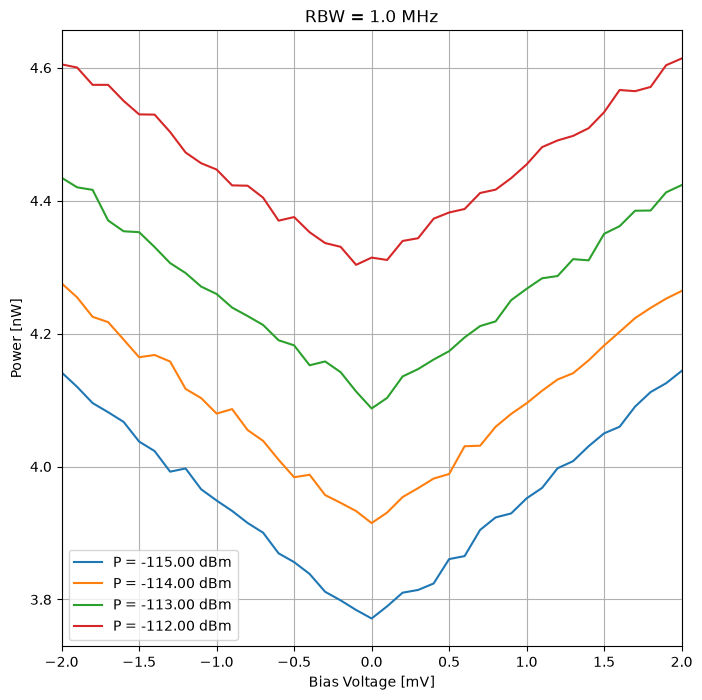

In [52]:
legend = []
fig, ax = plt.subplots(figsize=(8, 8))    
#plt.gca().set_prop_cycle(color=plt.cm.turbo(np.linspace(0,1,4)))

for index in np.arange(4):
    plt.plot(1000*np.array(scans[0]['noise_bias'])*2/200,np.array(scans[0]['noise'][index])/1e-9)
    legend.append(f"P = {scans[0]['power'][index] - 25 - 60:.2f} dBm")
plt.legend(legend,loc='lower left')
plt.xlim(-2,2)
#plt.ylim(1.04,1.1)
plt.xlabel('Bias Voltage [mV]')
plt.ylabel('Power [nW]')
plt.grid()
plt.title('RBW = '  + str(scans[0]['rbw']/1e6) + " MHz")
#plt.axhline(y=1.075, color='r', linestyle='--', label='Threshold')